# Proyecto Base - Evaluación de Minería de Datos

## Información del Grupo

- **Nombre o Número de Grupo:**
- **Sección:** 002D
- **Fecha de Entrega:** 26-05-2026
---

## Integrantes del Grupo (máximo 3 estudiantes)

### Estudiante 1
- **Nombre:** Ignacio
- **Apellido:** Ruz Aguilar
- **Correo institucional:** ig.ruz@duocuc.cl

### Estudiante 2 *(opcional)*
- **Nombre:** Claudio
- **Apellido:** Galiano Gonzalez
- **Correo institucional:** cl.galiano@duocuc.cl

## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), utilizada ampliamente para abordar proyectos de ciencia de datos y machine learning. Se compone de seis fases fundamentales como el entendimiento del negocio, los datos, preparacion de los datos, la etapa de modelado, su evaluacion de las metricas o el rendimiento de este junto a una etapa de despliegue en una funcion


## 1. Comprensión del Negocio
---
Este conjunto de datos contiene información sobre el proceso de admisión universitaria, con variables clave que permiten analizar la relación entre diferentes factores académicos y la aceptación de los solicitantes.

En pocas palabras la admision para en este caso para la Universidad de Santiago depende muchas veces de la carrera, pero las metricas como el nem, el puntaje de la PAES son factores muy influyentes para ser admitido a esta universidad.

Estos datos son ideales para realizar análisis exploratorios, entrenar modelos predictivos y estudiar los factores que influyen en las decisiones de admisión.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Escriba aqui sus codigos
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns

!pip install category_encoders

import category_encoders as ce

df = pd.read_csv('/content/drive/MyDrive/Mineria de Datos/Evaluacion 1/Nuevo Dataset Entrega 2 /AdmisionUes.csv')
pd.options.display.max_columns = None
pd.options.display.max_rows = 9999
pd.options.display.max_colwidth = None

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.5 MB/s eta 0:00:00


## 2. Comprensión de los Datos
Aca podemos entender que nuestros datos no usan un puntaje de recorte que es lo que frecuentemente pasa en las universidades para revisar tu admision por ende. Este dataset conformados por 4 columnas 2 cualitivas y 2 cuantitivas y estas son:

admit: Si el estudiante fue admitido en la universidad esta no contempla el puntaje de recorte pues esta en base a una media para esto

paes: puntaje de los estudiantes que tuvieron en la prueba

nem: promedio general de enseñanza media

rank: ranking del liceo donde si es 1 es por que superan el promedio general de un liceo

In [3]:
df.head(5)

,Unnamed: 0,admit,paes,nem,rank
0,1,0,328,6.4,2
1,2,1,636,6.5,2
2,3,1,986,6.8,4
3,4,1,599,6.0,1
4,5,0,441,5.7,1


In [4]:
df.shape #Cantidad de filas y columnas

(1813, 5)

## 3. Preparación de los Datos
Como podemos ver en el primer describe la preparacion de datos no sera compleja ya que cada columna contiene valores numericos para el entramiento de un modoelo, por ende vamos analizar directamente la aparicion de outliers por ejemplo (personas admitidas con bajo nem o puntajes que sean = 0)

In [5]:
print("\nInformación de columnas:") #TIPOS DE DATS
df.info()


Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1813 entries, 0 to 1812
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1813 non-null   int64  
 1   admit       1813 non-null   int64  
 2   paes        1813 non-null   int64  
 3   nem         1813 non-null   float64
 4   rank        1813 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 70.9 KB


In [6]:
print("\nValores nulos:")
print(df.isna().sum())


Valores nulos:
Unnamed: 0    0
admit         0
paes          0
nem           0
rank          0
dtype: int64


No muestra valores nulos porque son todos numericos si hay un outlier por ahi es porque su valor es 0 o se pasa de la metrica por ejemplo nem de 8 o puntaje 0 o negativo

In [7]:
# Nuestro primer paso sera la eliminacion de columnas que hacen ruido como Unnamed: 0
df = df.drop(columns=['Unnamed: 0'])

Es una columna autogenerada que hace un conteo de filas innecesario para el modeloo

In [8]:
df.describe().round(2)

,admit,paes,nem,rank
count,1813.00,1813.00,1813.00,1813.00
mean,0.31,493.11,5.91,2.76
std,0.46,154.52,0.50,1.05
min,0.00,126.00,4.50,1.00
25%,0.00,394.00,5.50,2.00
50%,0.00,468.00,5.90,3.00
75%,1.00,549.00,6.30,4.00
max,1.00,986.00,6.80,4.00


Aqui vemos que el nem ni la paes contiene valores fuera de lo previsto. el mayor nem es de 6.8 que es aceptable para estudiantes y el mayor puntaje de la paes fue 986 puntos, que es algo realista y demostracion de excelencia academica

#### 3.1 Depuración de Datos
- Detección y tratamiento de outliers

In [9]:
# Función para obtener límites de outliers
def obtener_limites_iqr(df, columna):
    Q1 = df[columna].quantile(0.25) #Sacamos el primer cuantil que seria el primer 25% de la distribucion
    Q3 = df[columna].quantile(0.75) #El tercer cuantil es desde el 75% al 100% para revisar cuales son los outliers
    IQR = Q3 - Q1 # representa el 50% central de tus datos
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

Por que multiplicamos el IQR por 1.5?

este límite permite capturar el 99.3% de los datos en una distribución normal, dejando fuera solo aquellos valores que están a más de 2.7 desviaciones estándar, los cuales consideramos atípicos o ruidosos para nuestro modelo de admisión

In [10]:
# Analizar PAES
inf_paes, sup_paes = obtener_limites_iqr(df, 'paes')
outliers_paes = df[(df['paes'] < inf_paes) | (df['paes'] > sup_paes)]

# Analizar NEM
inf_nem, sup_nem = obtener_limites_iqr(df, 'nem')
outliers_nem = df[(df['nem'] < inf_nem) | (df['nem'] > sup_nem)]

print(f"PAES: Límites [{inf_paes:.1f}, {sup_paes:.1f}]. Outliers detectados: {len(outliers_paes)}") #Casos extremos alumnos con puntaje muy bajo o muy alto respecto a una distribucion normal
print(f"NEM:  Límites [{inf_nem:.1f}, {sup_nem:.1f}]. Outliers detectados: {len(outliers_nem)}") #Casos extemos de mal nem o un nem exagerado fuera de lo "tipico"

PAES: Límites [161.5, 781.5]. Outliers detectados: 106
NEM:  Límites [4.3, 7.5]. Outliers detectados: 0


Se optó por no eliminar los outliers detectados en la variable PAES mediante el método IQR (106 registros), tras verificar que estos corresponden a puntajes de excelencia académica y no a errores de ingreso. Eliminar estos registros resultaría en una pérdida crítica de información sobre la clase minoritaria (alumnos admitidos), sesgando el modelo hacia los casos de rechazo

Debido a los limites superiores es un calculo entre el 75% de los datos, junto al rango intercualtil esto nos dio un rango "sesgado" para esta distribucion, pero viendo anteriormente el .describe() la mejor nota fue de 6.8 por ende los datos si se encuentran entre un rango de 4.3 a 7.0 por ende no se encuentran valores atipicos para este dataset

In [11]:
# Filtramos y mostramos los top 10 puntajes
excelencia = df[df['paes'] > 781.5].sort_values(by='paes', ascending=False)
print("Top 10 alumnos por puntaje PAES:")
print(excelencia[['paes', 'nem', 'rank', 'admit']].head(10))

Top 10 alumnos por puntaje PAES:
     paes  nem  rank  admit
2     986  6.8     4      1
25    986  6.5     4      1
461   986  6.2     2      1
286   986  6.0     4      1
234   986  6.3     4      1
173   986  6.2     3      1
150   986  6.5     4      1
118   986  6.5     4      1
687   986  6.8     4      1
642   986  5.8     3      1


¿Por que hay personas con buen nem y ranking de 4?

Esto sucede porque el Ranking no mide solo tu nota individual, sino cuánto destacas tú en comparación con el promedio de notas de tu propia generación y el promedio histórico de tu liceo.

#### 3.2 Encoding (no aplica)
- En este caso no usaremos encoder debido a que las unicas categoricas existentes son admit que son valores de 0 y 1 osea ya esta aplicado el encoder y el rank se puede estipular que sirve como un ordinal encoder donde 1 es el mayor y 4 el peor en pocas palabras


## 4. Análisis Exploratorio
Aqui veremos como las variables como el nem, ranking y las paes se relacionan directamente con nuestra variable objetivo que sera admit. Veremos sus distribuciones y correlaciones

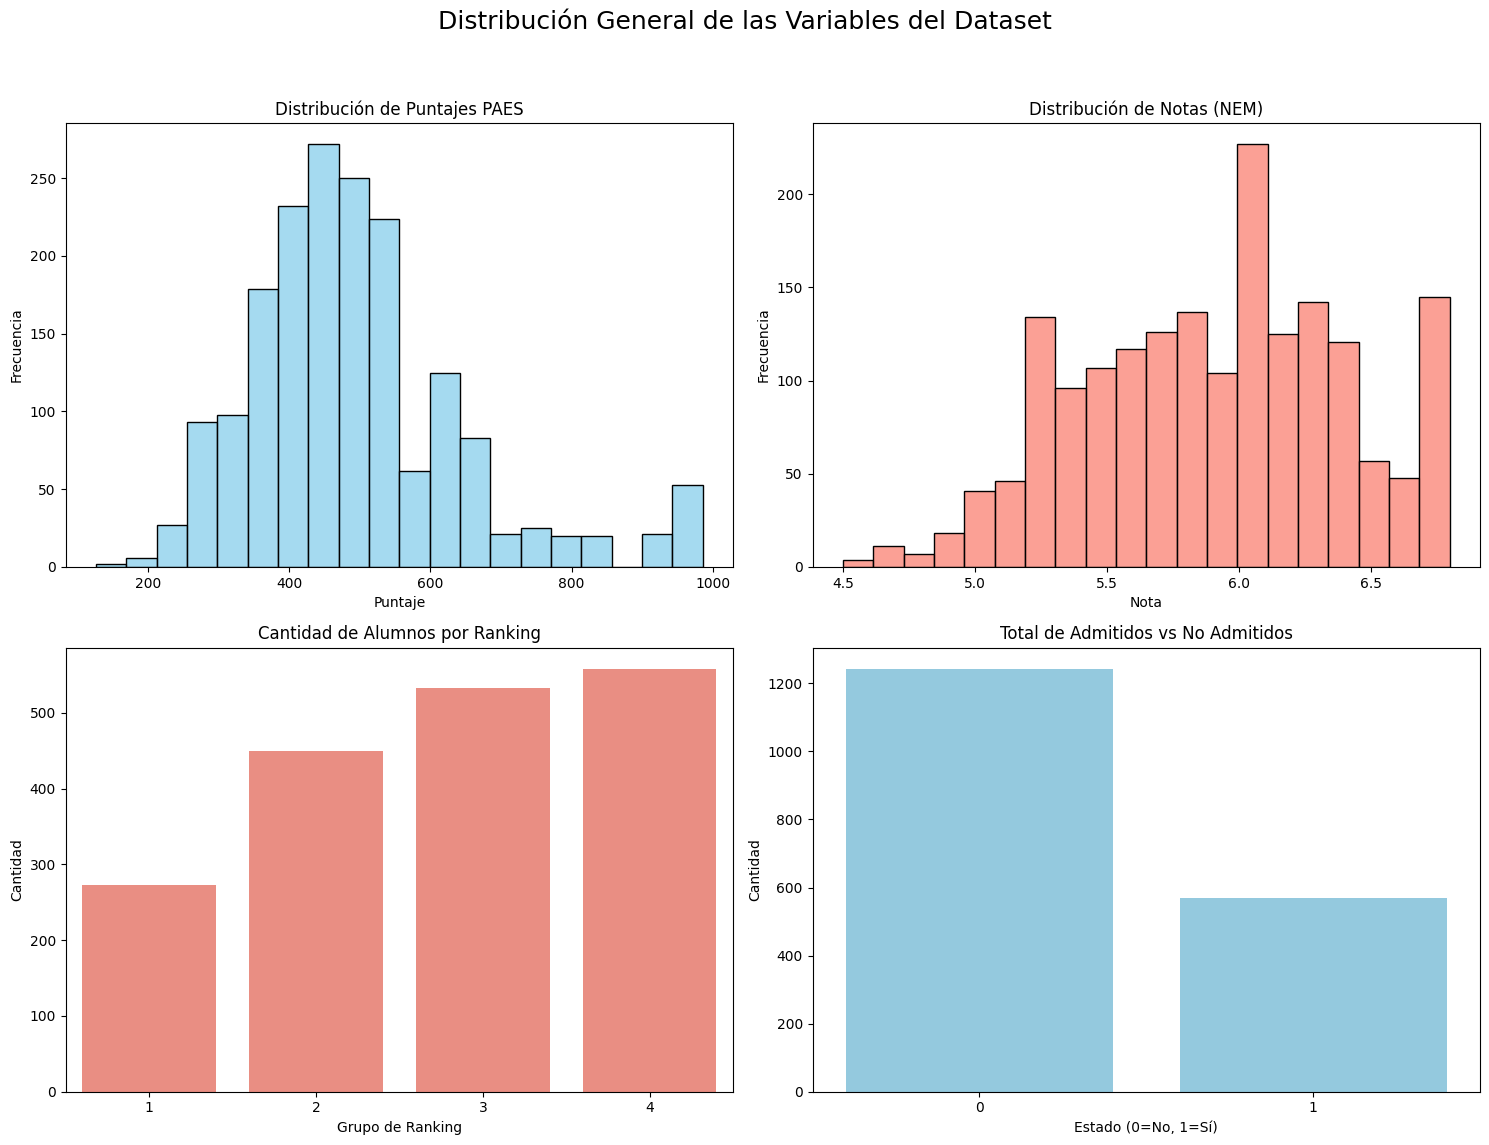

In [12]:
# Configuramos el lienzo para 4 gráficos (2 filas y 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Distribución General de las Variables del Dataset', fontsize=18)

# Histograma de PAES
sns.histplot(df['paes'], bins=20, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Puntajes PAES')
axes[0, 0].set_xlabel('Puntaje')
axes[0, 0].set_ylabel('Frecuencia')

# Histograma de NEM
sns.histplot(df['nem'], bins=20, color='salmon', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Notas (NEM)')
axes[0, 1].set_xlabel('Nota')
axes[0, 1].set_ylabel('Frecuencia')

# Histograma de RANKING
sns.countplot(x='rank', data=df, color='salmon', ax=axes[1, 0])
axes[1, 0].set_title('Cantidad de Alumnos por Ranking')
axes[1, 0].set_xlabel('Grupo de Ranking')
axes[1, 0].set_ylabel('Cantidad')

# Histograma de ADMISIÓN (Variable Objetivo)
sns.countplot(x='admit', data=df, color='skyblue', ax=axes[1, 1])
axes[1, 1].set_title('Total de Admitidos vs No Admitidos')
axes[1, 1].set_xlabel('Estado (0=No, 1=Sí)')
axes[1, 1].set_ylabel('Cantidad')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

El análisis de las distribuciones muestra que la PAES se concentra en el rango medio (380-550 puntos), indicando que los puntajes de excelencia son escasos y competitivos. El NEM presenta un sesgo hacia notas altas (5.5-6.5), lo que sugiere que el perfil general es académicamente responsable. El Ranking está equilibrado en sus cuatro niveles, mientras que la variable de Admisión confirma que existe una mayor cantidad de rechazados que admitidos, reflejando la selectividad del proceso y la necesidad de un modelo preciso para identificar a los candidatos exitosos.

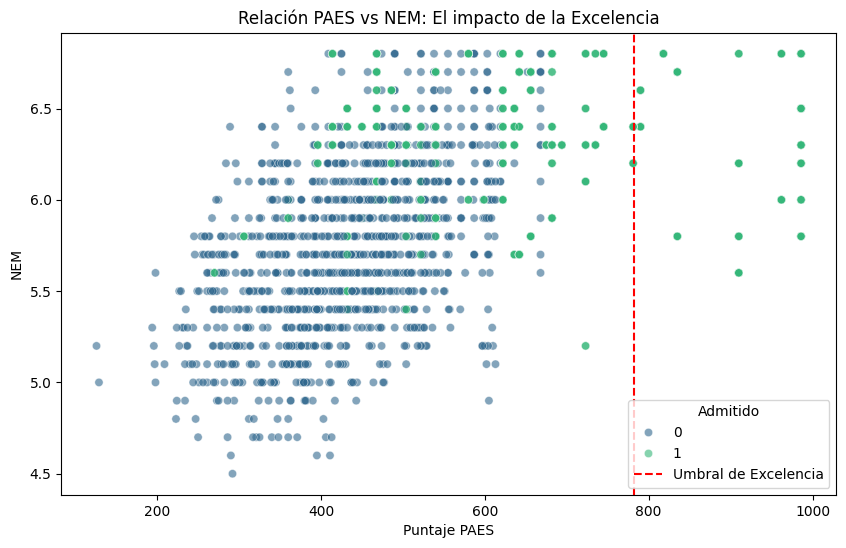

In [13]:

plt.figure(figsize=(10, 6))
# Dibujamos todos los puntos
sns.scatterplot(data=df, x='paes', y='nem', hue='admit', palette='viridis', alpha=0.6)

# Dibujamos la línea que marca la excelencia
plt.axvline(781.5, color='red', linestyle='--', label='Umbral de Excelencia')

plt.title('Relación PAES vs NEM: El impacto de la Excelencia')
plt.xlabel('Puntaje PAES')
plt.ylabel('NEM')
plt.legend(title='Admitido')
plt.show()

Este grafico nos da entender la importancia y correlacion que pueden a llegar a tener estas 2 variables dandonos a entender que si obtienes un buen nem mayor a 5 y un puntaje mayor de 700 puntos quedaras admitido en la universidad. Nos podemos dar cuenta tambien que lo que mas peso entrega a la admision es el puntaje de la paes mas que el nem ya que hay personas con un nem alto que no fue admitido aqui es donde entra el ranking del estudiando que aplico

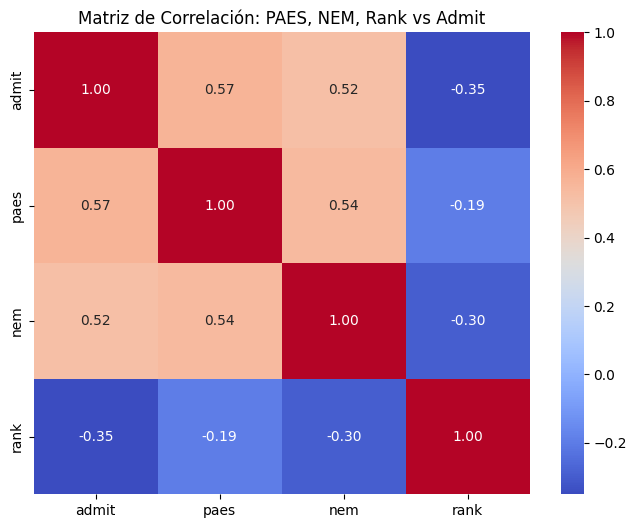

In [14]:
# Calculamos la matriz de correlación
corr = df.corr()

# Dibujamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: PAES, NEM, Rank vs Admit')
plt.show()

Tras analizar la relación entre las variables académicas y el éxito en la admisión, se desprenden los siguientes hallazgos clave:

La PAES como Predictores Principal (0.57): Existe una correlación positiva fuerte entre el puntaje PAES y la admisión. Esto indica que el desempeño en la prueba es el factor con mayor peso estadístico para determinar si un alumno es aceptado. Desde el punto de vista del modelo, esta variable será la que genere las particiones más importantes en los árboles de decisión.

Influencia Moderada del NEM (0.52): El promedio de notas de enseñanza media presenta una correlación positiva moderada-baja. Aunque contribuye a la probabilidad de ingreso, no es un factor determinante por sí solo. Esto sugiere que un buen NEM ayuda, pero no garantiza la admisión si el puntaje PAES es insuficiente.

 Correlaciones negativas del Ranking (-0.35): existe una relación inversa, mientras mejor es tu posición en el ranking (número más pequeño), más chances tienes de entrar.

/tmp/ipykernel_877/423060441.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='rank', y='admit', palette='magma')


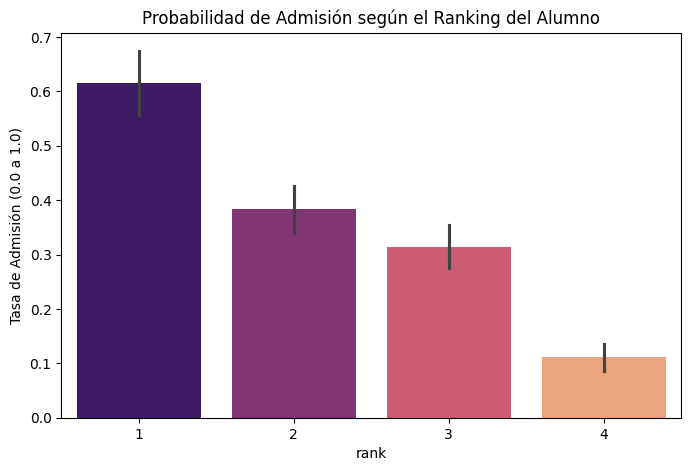

In [15]:
# Gráfico de barras de tasa de admisión por Rank
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='rank', y='admit', palette='magma')
plt.title('Probabilidad de Admisión según el Ranking del Alumno')
plt.ylabel('Tasa de Admisión (0.0 a 1.0)')
plt.show()

El gráfico muestra una relación inversamente proporcional: a medida que el valor del ranking aumenta, la probabilidad de ser admitido disminuye drásticamente.

Rank 1: Tiene la probabilidad más alta de éxito (casi un 55% de los alumnos en esta categoría son admitidos).

Rank 4: Tiene la probabilidad más baja (apenas supera el 15%).

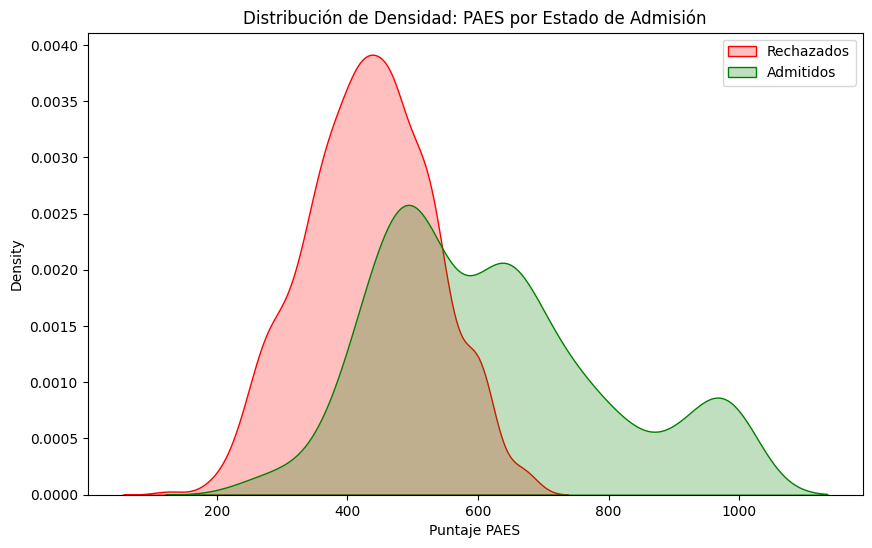

'En un gráfico de densidad (KDE), el área total bajo la curva debe ser siempre igual a 1 (representa el 100% de los datos).\ndonde la curva es más alta, es donde se concentra la mayor cantidad de alumnos.\n'

In [16]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['admit'] == 0], x='paes', label='Rechazados', fill=True, color='red')
sns.kdeplot(data=df[df['admit'] == 1], x='paes', label='Admitidos', fill=True, color='green')
plt.title('Distribución de Densidad: PAES por Estado de Admisión')
plt.xlabel('Puntaje PAES')
plt.legend()
plt.show()

"""En un gráfico de densidad (KDE), el área total bajo la curva debe ser siempre igual a 1 (representa el 100% de los datos).
donde la curva es más alta, es donde se concentra la mayor cantidad de alumnos.
"""

El gráfico nos muestra que la PAES no es una regla matemática perfecta. Entre los 450 y 650 puntos existe una zona de incertidumbre donde el puntaje no garantiza nada, y es ahí donde el modelo de Minería de Datos tendrá que buscar otros factores (como el NEM o el Rank) para entender por qué unos entran y otros no.

/tmp/ipykernel_877/3681010861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='admit', y='nem', palette='Set2')


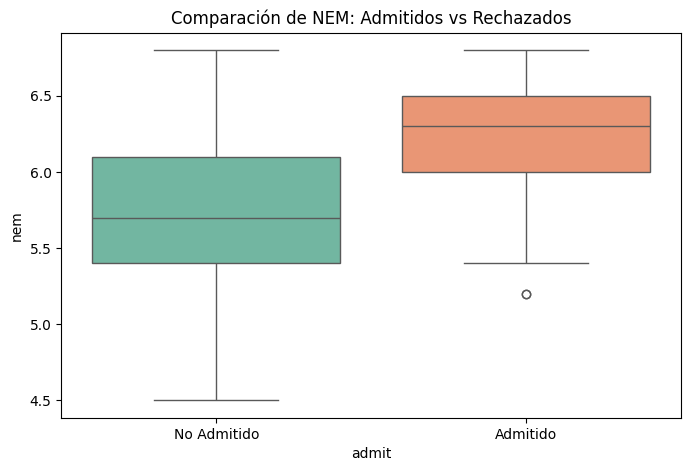

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='admit', y='nem', palette='Set2')
plt.title('Comparación de NEM: Admitidos vs Rechazados')
plt.xticks([0, 1], ['No Admitido', 'Admitido'])
plt.show()

Al mirar el gráfico, queda claro que tener buenas notas ayuda, pero no es una garantía mágica. Si te fijas, los alumnos que sí entraron (la caja naranja) tienen notas más altas en general que los que quedaron fuera. Esto significa que ser un alumno responsable durante la enseñanza media te da una ventaja importante.

## 5. Modelado
Haremos pruebas con 2 modelos distintos y nos quedaremos con las mejores metricas usaremos

Naive Bayes: principalmente se usa para clasificar datos en diferentes categorías. Es un algoritmo de Machine Learning supervisado que calcula la probabilidad de que un elemento pertenezca a una clase determinada basándose en sus características

Arbol de decision: es un modelo de Machine Learning que sirve tanto para clasificar datos como para predecir valores numéricos (regresión). Funciona como un diagrama de flujo que toma decisiones complejas rompiéndolas en una serie de preguntas simples de "sí o no".

In [18]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

In [19]:
X = df.drop(columns=['admit'])
y = df['admit']

# Creamos datos de validacion y entrenaiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ahora escalamos para que el modelo funcione bien
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Lo primero que hacemos es eliminar nuestra variable objetivo del eje X los modelos normalmente funcionan como un plano cartesiano donde buscan por proximidad estadistica a un punto referencia. Por eso nosotros evaluaremos la distancia que hay del entre el eje y al x para hacer predicciones de clasificacion

In [20]:
# Calculamos la entropia
def entropy(data):
    classes = np.unique(data)
    entropies = []
    for c in classes:
        p = sum(data == c) / len(data)
        current_entropy = p * np.log2(p)
        entropies.append(current_entropy)
    return -1 * sum(entropies)

In [21]:
entropy(df.admit)

np.float64(0.8981829149797134)

La entropia nos entrega que tan desornado esta donde mientras mas cerca a 0 la variable es mas "pura" y mientras mas cercano al 1 es por que tiene un desorden alto individualmente

In [22]:
# Escenario A: Alumnos con puntaje alto (Excelencia)
# Veremos que la entropía aquí debería ser baja porque casi todos entran
print(f"Entropía alumnos PAES >= 750: {entropy(df.admit[df.paes >= 750])}")

# Escenario B: Alumnos con puntaje bajo
print(f"Entropía alumnos PAES < 450: {entropy(df.admit[df.paes < 450])}")

# Escenario C: La "Zona de Confusión" (donde se mezclan)
print(f"Entropía alumnos PAES entre 500 y 600: {entropy(df.admit[(df.paes >= 500) & (df.paes <= 600)])}")

Entropía alumnos PAES >= 750: -0.0
Entropía alumnos PAES < 450: 0.47148013163320646
Entropía alumnos PAES entre 500 y 600: 0.8973678197424808


Antes de entrenar, exploramos manualmente la ganancia de información. Notamos que al filtrar por PAES >= 750, la entropía caía drásticamente hacia 0 (grupo puro), mientras que en el rango medio la entropía se mantenía alta pero con un valor mas bajo que viendo la variable individualmente, justificando por qué el modelo necesita más variables para decidir.

## 6. Entrenamiento y Evaluación
Aqui como nuestra variable objetivo sera una variable de clasificacion usaremos Naive Bayes y Arboles de decesion para la evaluacion del modelo a partir de estas metricas

Exactitud Accuracy: Mide el porcentaje total de predicciones correctas. No es confiable si las clases están desbalanceadas.Precisión

Precision: De todos los que el modelo clasificó como positivos, cuántos realmente lo eran. Evita los falsos positivos.Sensibilidad

Recall: De todos los positivos reales que existían, cuántos logró detectar el modelo. Evita los falsos negativos.

AUC-ROC: Mide la capacidad del modelo para separar una clase de la otra a través de diferentes umbrales de decisión.


In [23]:
# Arbol de decision
# Usamos el criterio de entropía para que el modelo haga los cálculos que hicimos arriba automáticamente
modelo_arbol = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Entrenamos con los datos del split (X_train, y_train ya definidos arriba)
modelo_arbol.fit(X_train, y_train)

# Predicciones y Métricas
y_pred = modelo_arbol.predict(X_test)
y_prob = modelo_arbol.predict_proba(X_test)[:, 1]

print("\n--- MÉTRICAS FINALES ---")
print(f"Accuracy:  {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {metrics.recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {metrics.roc_auc_score(y_test, y_prob):.4f}")


--- MÉTRICAS FINALES ---
Accuracy:  0.8843
Precision: 0.8333
Recall:    0.7895
ROC-AUC:   0.9136


Podemos decir que el modelo predice el 88% de los casos tambien exhibe una clara tendencia a ser "estricto" o conservador en sus predicciones.

Su Precision (83.33%) nos dice que cuando el modelo asegura que un alumno será "Admitido", es muy confiable. Genera pocos falsos positivos (evitando darle falsas esperanzas a estudiantes que finalmente serán rechazados).

Su Recall (78.95%) es su punto más débil. El modelo no logra detectar a cerca de un 21% de los alumnos que sí lograron matricularse en la vida real (falsos negativos).

Tambien su ROC-AUC nos indica lo bien que puede separar de los dos grupos de alumnos adminitidos y no admitidos

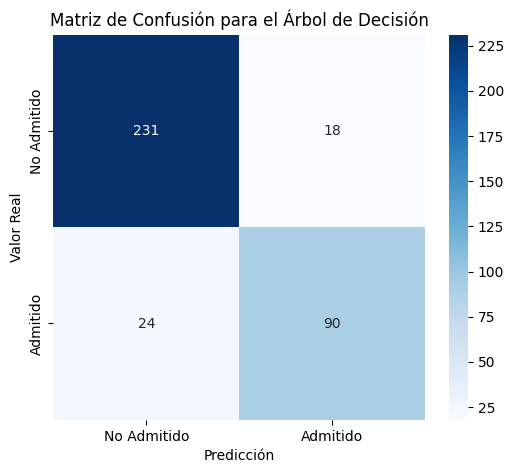

In [24]:
# Calculamos la matriz de confusión
cm = metrics.confusion_matrix(y_test, y_pred)

# Visualizamos la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Admitido', 'Admitido'],
            yticklabels=['No Admitido', 'Admitido'])
plt.title('Matriz de Confusión para el Árbol de Decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Podemos que los resultados del modelo fueron correctos pero fallo en 18 registros entregando falsos positivos, esto quiere decir que el modelo predijo que 18 alumnos seria admitidos pero realmente no fue asi, tambien vemos 24 falsos negativos donde el modelo predijo que 24 estudiantes no serian admitidos pero en realidad si fueron admitidos

In [25]:
#Naive Bayes
#Instanciar el modelo (GaussianNB asume que los datos siguen una curva normal)
modelo_nb = GaussianNB()

#Entrenamiento (Usamos los datos que ya tienes separados y escalados)
modelo_nb.fit(X_train_scaled, y_train)

#Predicciones
y_pred_nb = modelo_nb.predict(X_test_scaled)
y_prob_nb = modelo_nb.predict_proba(X_test_scaled)[:, 1]

#Evaluación con las métricas que definimos
print("--- MÉTRICAS NAIVE BAYES ---")
print(f"Accuracy:  {metrics.accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {metrics.recall_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC:   {metrics.roc_auc_score(y_test, y_prob_nb):.4f}")

--- MÉTRICAS NAIVE BAYES ---
Accuracy:  0.8099
Precision: 0.7228
Recall:    0.6404
ROC-AUC:   0.8887


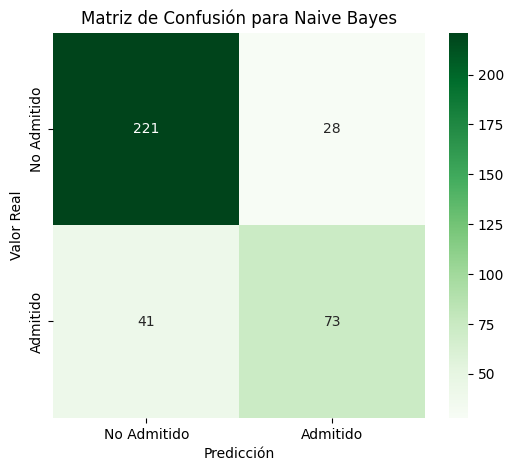

In [26]:
# Calculamos la matriz de confusión para Naive Bayes
cm_nb = metrics.confusion_matrix(y_test, y_pred_nb)

# Visualizamos la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Admitido', 'Admitido'],
            yticklabels=['No Admitido', 'Admitido'])
plt.title('Matriz de Confusión para Naive Bayes')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Este modelo es muy similar en sus metricas al arbol de decision  pero su recall es mas bajo donde el modelo no detecta alrededor 36% de los alumns que si fueron admitidos. La matriz de confusion nos proporciona esto dandonos el claro ejemplo que encontro mas falsos negativos y falsos positivo que el arbol de decision

## 7. Despliegue (opcional)
Decidimos quedarnos con un solo modelo que sera el arbol decision debido que todas sus metricas fueron mayores que las de Naive Bayes, igualmente para futuro podremos evaluar distintos modelos clasificatorios

In [27]:
def simular_admision_arbol(paes, nem, rank):
    # Creamos el DataFrame con los nombres de columnas correctos
    datos_entrada = pd.DataFrame([[paes, nem, rank]], columns=['paes', 'nem', 'rank'])

    # NO ESCALAMOS para el árbol, ya que modelo_arbol.fit se hizo con X_train (original)
    prediccion = modelo_arbol.predict(datos_entrada)[0]
    probabilidad = modelo_arbol.predict_proba(datos_entrada)[0][1]

    print(f"--- Análisis del Perfil (Árbol de Decisión) ---")
    print(f"PAES: {paes} pts | NEM: {nem} | Grupo Ranking: {rank}")
    print(f"Certeza de Admisión (en su hoja): {probabilidad:.2%}")
    print("------------------------------------------------")

    if prediccion == 1:
        return "Resultado: ADMITIDO. El perfil cumple con los umbrales estadísticos."
    else:
        return "Resultado: NO ADMITIDO. El perfil cae en una categoría de bajo ingreso histórico."

In [28]:
# Ejemplo
print(simular_admision_arbol(500, 6.4, 1))

--- Análisis del Perfil (Árbol de Decisión) ---
PAES: 500 pts | NEM: 6.4 | Grupo Ranking: 1
Certeza de Admisión (en su hoja): 59.72%
------------------------------------------------
Resultado: ADMITIDO. El perfil cumple con los umbrales estadísticos.


Para que nos sirve este despliegue?

Este despliegue nos funcionara en caso de que sea necesario externalizar este analisis a un servicio ya sea mediante el POST de una API con un cuerpo JSON sencillo a traves de una interfaz grafica, donde le pasas estos valores y esta funcion se encarga de leer los datos y entregar un resultado

---
### Conclusiones para este primer modelo

Podemos que el modelo funciona correctamente para clasificar teniendo un porcentaje muy bajo de error esto nos da entender que para un ambiente productivo podria funcioonar si es se llega a dar el caso que la admision a las universidades fuera a traves de una media pero la verdad es que para estudiar una carrera en especifico hay un puntaje de recorte que implementaremos a modo de simulacion utilizando arboles de decision

## Simulacion: Agregando puntajes de recortes (WEB SCRAPPING)

Haremos el scrapping de esta pagina de la universidad de santiago:https://admision.usach.cl/busca-tu-carreras

Usaremos la columna carrera y ultima matricula como el puntaje de corte debido que los puntajes de corte son poderados y dependen del nem y el ranking. Por eso usaremos la ultrima matricula que fue el ultimo lugar que ocupo un matriculante de la carrera

In [29]:
# 1. Instalar el parseador lxml por si acaso (necesario para leer tablas HTML en Pandas)
!pip install -q lxml beautifulsoup4 requests

# 2. Importar las herramientas esenciales
import pandas as pd
import requests
from bs4 import BeautifulSoup
import re

print("Ajuste de entorno completado con éxito.")

Ajuste de entorno completado con éxito.


In [30]:
# 1. Definir la URL oficial del buscador de carreras de la USACH
url_usach = "https://admision.usach.cl/busca-tu-carreras"

# 2. Configurar los headers para simular un navegador real
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# 3. Realizar la petición HTTP
print("Conectando con el portal de Admisión USACH...")
response = requests.get(url_usach, headers=headers)

# 4. Verificar si la descarga fue exitosa
if response.status_code == 200:
    print("¡Conexión exitosa! El HTML se ha descargado correctamente.")
    # Creamos el objeto BeautifulSoup para empezar a analizar la estructura
    soup = BeautifulSoup(response.text, 'html.parser')
else:
    print(f"Error de conexión. Código de estado: {response.status_code}")

Conectando con el portal de Admisión USACH...
¡Conexión exitosa! El HTML se ha descargado correctamente.


Ahora vamos a inspeccionar las filas y columnas desde la primera fila para saber la posicion que necesitamos

In [31]:
# 1. Volvemos a buscar la tabla en el objeto soup
tabla = soup.find('table')

if tabla:
    filas = tabla.find_all('tr')

    # Tomamos la primera fila con datos reales (usualmente la del índice 1)
    fila_ejemplo = filas[1]
    celdas_ejemplo = fila_ejemplo.find_all(['td', 'th'])

    print(f"La fila tiene un total de {len(celdas_ejemplo)} columnas.")
    print("Contenido encontrado por cada columna:")
    print("-" * 50)

    # Imprimimos el índice y el texto para mapear la tabla real
    for indice, celda in enumerate(celdas_ejemplo):
        print(f"Columna [{indice}]: {celda.text.strip()}")

else:
    print("No se pudo acceder a la tabla.")

La fila tiene un total de 20 columnas.
Contenido encontrado por cada columna:
--------------------------------------------------
Columna [0]: 16034
Columna [1]: ADMINISTRACIÓN Y ECONOMÍA
Columna [2]: ADMINISTRACIÓN PÚBLICA
Columna [3]: 10%
Columna [4]: 40%
Columna [5]: 15%
Columna [6]: 25%
Columna [7]: -
Columna [8]: 10%
Columna [9]: -
Columna [10]: 550
Columna [11]: 485
Columna [12]: 857,2
Columna [13]: 736,7
Columna [14]: Presencial
Columna [15]: Diurna
Columna [16]: 90
Columna [17]: 0
Columna [18]: 4
Columna [19]: 15


Extraemos el puntaje de corte y el nombre dee la carrera con el siguiente script

In [32]:
lista_carreras = []
lista_cortes = []
# Buscar todas las filas de datos (omitimos los encabezados de la tabla)
filas = tabla.find_all('tr')[1:]

for fila in filas:
    celdas = fila.find_all('td')
    if len(celdas) >= 14:
        # Extraemos el nombre de la carrera (Columna 2)
        nombre = celdas[2].text.strip()

        # Extraemos el puntaje del último matriculado (Columna 13)
        corte_texto = celdas[13].text.strip()
        corte_texto = corte_texto.replace(',', '.')

        try:
            # Convertimos el texto a número decimal
            puntaje_corte = float(corte_texto)
            lista_carreras.append(nombre)
            lista_cortes.append(puntaje_corte)
        except ValueError:
            continue
df_cortes_real = pd.DataFrame({
    'carrera': lista_carreras,
    'puntaje_corte': lista_cortes
})

print(f"¡Scraping finalizado con éxito! Registros reales guardados: {len(df_cortes_real)}")
print("\nVista previa de las primeras carreras y sus cortes oficiales:")
print(df_cortes_real.head(10))

¡Scraping finalizado con éxito! Registros reales guardados: 70

Vista previa de las primeras carreras y sus cortes oficiales:
                                       carrera  puntaje_corte
0                       ADMINISTRACIÓN PÚBLICA         736.70
1   ANÁLISIS Y GESTIÓN DE PROCESOS PRODUCTIVOS         506.45
2           ANALISTA EN COMPUTACIÓN CIENTÍFICA         674.10
3                                 ARQUITECTURA         727.10
4  ASTROFÍSICA CON MENCIÓN EN CIENCIA DE DATOS         723.60
5       BACHILLERATO EN CIENCIAS Y HUMANIDADES         767.80
6                                   BIOQUÍMICA         812.75
7          CONTADOR PÚBLICO Y AUDITOR (DIURNO)         707.75
8                                      DERECHO         775.30
9                DISEÑO EN COMUNICACIÓN VISUAL         686.20


Luego crearemos una funcion que asigne los puntajes de corte de forma coherente

In [33]:
df_nuevo = df.copy()
df_cortes_real = df_cortes_real.sort_values(by='puntaje_corte').reset_index(drop=True)

def asignar_datos_coherentes_y_cercanos(df_origen, df_cortes):
    carreras_finales = []
    cortes_finales = []

    for _, fila in df_origen.iterrows():
        paes_alumno = fila['paes']
        fue_admitido = fila['admit']

        if fue_admitido == 1:
            # ADMITIDOS: Buscamos carreras con corte menor o igual a su PAES
            opciones = df_cortes[df_cortes['puntaje_corte'] <= paes_alumno]
            if not opciones.empty:
                # Para que sea realista, elegimos entre las 3 carreras con corte más cercano por debajo de su puntaje
                seleccionado = opciones.tail(3).sample(1).iloc[0]
            else:
                seleccionado = df_cortes.iloc[0] # El corte más bajo de la U si su PAES es muy bajo

        else:
            # RECHAZADOS: Buscamos carreras con corte estrictamente MAYOR a su PAES
            opciones = df_cortes[df_cortes['puntaje_corte'] > paes_alumno]
            if not opciones.empty:
                #Tomamos las 3 carreras cuyo corte es el más cercano por encima de su puntaje
                seleccionado = opciones.head(3).sample(1).iloc[0]
            else:
                seleccionado = df_cortes.iloc[-1]

        carreras_finales.append(seleccionado['carrera'])
        cortes_finales.append(seleccionado['puntaje_corte'])

    return carreras_finales, cortes_finales

print("Asignando carreras reales con penalización y cercanía coherente...")
lista_carreras, lista_cortes = asignar_datos_coherentes_y_cercanos(df_nuevo, df_cortes_real)

df_nuevo['carrera'] = lista_carreras
df_nuevo['puntaje_corte'] = lista_cortes
#Calculo de la brecha de puntaje
df_nuevo['brecha_puntaje'] = df_nuevo['paes'] - df_nuevo['puntaje_corte']

print("¡Dataset optimizado con éxito!")
print("-" * 50)
print("Distribución de las brechas en los rechazados (Deberían ser negativas pero pequeñas):")
print(df_nuevo[df_nuevo['admit'] == 0]['brecha_puntaje'].describe())

Asignando carreras reales con penalización y cercanía coherente...
¡Dataset optimizado con éxito!
--------------------------------------------------
Distribución de las brechas en los rechazados (Deberían ser negativas pero pequeñas):
count    1243.000000
mean      -67.263395
std        61.942783
min      -352.700000
25%       -99.500000
50%       -46.750000
75%       -19.600000
max        -0.350000
Name: brecha_puntaje, dtype: float64


Verificaremos outliers y vemos como quedo la distribucion

In [34]:
variables_analisis = ['paes', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje']

print("=== RESUMEN ESTADÍSTICO DEL DATASET ENRIQUECIDO ===")
print(df_nuevo[variables_analisis].describe())

print("\n=== DISTRIBUCIÓN DE ALUMNOS ADMITIDOS VS RECHAZADOS ===")
print(df_nuevo['admit'].value_counts(normalize=True) * 100)

=== RESUMEN ESTADÍSTICO DEL DATASET ENRIQUECIDO ===
              paes          nem         rank  puntaje_corte  brecha_puntaje
count  1813.000000  1813.000000  1813.000000    1813.000000     1813.000000
mean    493.107005     5.906122     2.758411     533.639244      -40.532239
std     154.516249     0.498066     1.049068     103.965761       70.960429
min     126.000000     4.500000     1.000000     457.500000     -352.700000
25%     394.000000     5.500000     2.000000     462.450000      -70.450000
50%     468.000000     5.900000     3.000000     478.700000      -25.500000
75%     549.000000     6.300000     4.000000     556.750000        1.800000
max     986.000000     6.800000     4.000000     937.800000      173.250000

=== DISTRIBUCIÓN DE ALUMNOS ADMITIDOS VS RECHAZADOS ===
admit
0    68.560397
1    31.439603
Name: proportion, dtype: float64


In [35]:
# Aislar los outliers de negocio: Admitidos con brecha negativa
outliers_infiltrados = df_nuevo[(df_nuevo['admit'] == 1) & (df_nuevo['brecha_puntaje'] < 0)]

print(f"=== ANÁLISIS DE OUTLIERS DE NEGOCIO ===")
print(f"Total de alumnos admitidos con brecha negativa detectados: {len(outliers_infiltrados)}")

# Aislar los casos donde NO fueron admitidos pero tenían brecha positiva
outliers_no_admitidos = df_nuevo[(df_nuevo['admit'] == 0) & (df_nuevo['brecha_puntaje'] >= 0)]

print("\n" + "=" * 60)
print(f"=== ANÁLISIS DE NO ADMITIDOS CON BRECHA POSITIVA ===")
print(f"Total de alumnos no admitidos con brecha positiva detectados: {len(outliers_no_admitidos)}")


=== ANÁLISIS DE OUTLIERS DE NEGOCIO ===
Total de alumnos admitidos con brecha negativa detectados: 84

=== ANÁLISIS DE NO ADMITIDOS CON BRECHA POSITIVA ===
Total de alumnos no admitidos con brecha positiva detectados: 0


Podemos identificar en esta tabla que hubieron 84 personas en total que tuvieron una brecha negativa y fueron admitidos estos registros no cumplen con las reglas de negocio

Accion a realizar: Eliminaremos estos outliers y como vimos la distribucion entre admitidos extenderemos el dataset con registros de personas que fueron admitidas

In [36]:
# Identificar los índices de los outliers a eliminar
indices_a_eliminar = outliers_infiltrados.index

# Eliminar las filas correspondientes de df_nuevo
df_nuevo = df_nuevo.drop(indices_a_eliminar)

print(f"Se eliminaron {len(indices_a_eliminar)} filas outlier.")
print(f"Nuevo tamaño de df_nuevo: {len(df_nuevo)} filas.")

Se eliminaron 84 filas outlier.
Nuevo tamaño de df_nuevo: 1729 filas.


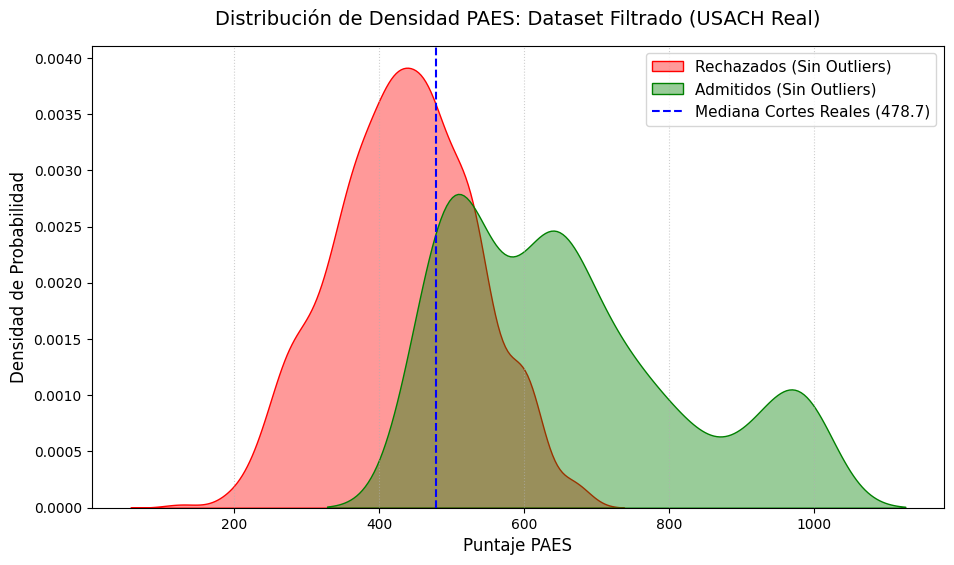

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6))
sns.kdeplot(data=df_nuevo[df_nuevo['admit'] == 0], x='paes', label='Rechazados (Sin Outliers)', fill=True, color='red', alpha=0.4)

sns.kdeplot(data=df_nuevo[df_nuevo['admit'] == 1], x='paes', label='Admitidos (Sin Outliers)', fill=True, color='green', alpha=0.4)

# 4. Estética y etiquetas del gráfico
plt.title('Distribución de Densidad PAES: Dataset Filtrado (USACH Real)', fontsize=14, pad=15)
plt.xlabel('Puntaje PAES', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)

plt.axvline(x=df_nuevo['puntaje_corte'].median(), color='blue', linestyle='--', label=f"Mediana Cortes Reales ({df_nuevo['puntaje_corte'].median():.1f})")

plt.legend(fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# 5. Desplegar gráfico
plt.show()

/tmp/ipykernel_877/8721819.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_nuevo, x='admit', palette=['#ff4d4d', '#33cc33'])


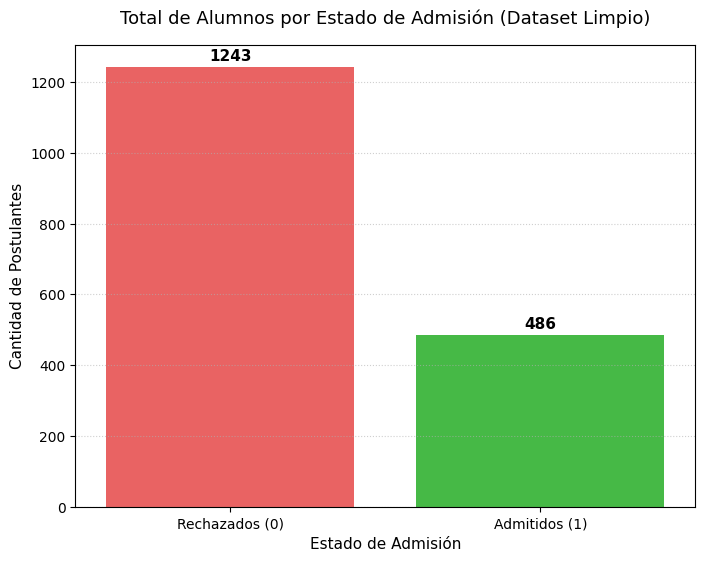

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el tamaño del lienzo
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_nuevo, x='admit', palette=['#ff4d4d', '#33cc33'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

plt.title('Total de Alumnos por Estado de Admisión (Dataset Limpio)', fontsize=13, pad=15)
plt.xlabel('Estado de Admisión', fontsize=11)
plt.ylabel('Cantidad de Postulantes', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Rechazados (0)', 'Admitidos (1)'])
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 5. Desplegar gráfico
plt.show()

Despues de ver este grafico para que el modelo no se overfitee tenemos que aumentar la población minoritaria.

## Aumento de la poblacion minoritaria

Usaremos la tecnica SMOTE que consiste en generar registros del grupo donde creamos mediante código nuevos registros de alumnos admitidos inventando puntajes PAES altos (ej. entre 700 y 900 puntos) y asignándoles carreras de la USACH de manera que su brecha sea positiva.

In [39]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

variables_numericas = ['paes', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje']
X_num = df_nuevo[variables_numericas]
y_num = df_nuevo['admit']

smote = SMOTE(random_state=42) #Smote crea nuevos registros
X_resampled, y_resampled = smote.fit_resample(X_num, y_num)

df_balanceado = pd.DataFrame(X_resampled, columns=variables_numericas)
df_balanceado['admit'] = y_resampled

df_balanceado['paes'] = df_balanceado['paes'].round().astype(int)
df_balanceado['rank'] = df_balanceado['rank'].round().astype(int)
df_balanceado['nem'] = df_balanceado['nem'].round(2)

print("=== BALANCEO CON SMOTE COMPLETADO ===")
print(f"Cantidad de filas antes de SMOTE: {len(df_nuevo)}")
print(f"Cantidad de filas después de SMOTE: {len(df_balanceado)}")
print("\nNueva distribución de clases (Perfectamente balanceada 50/50):")
print(df_balanceado['admit'].value_counts())

=== BALANCEO CON SMOTE COMPLETADO ===
Cantidad de filas antes de SMOTE: 1729
Cantidad de filas después de SMOTE: 2486

Nueva distribución de clases (Perfectamente balanceada 50/50):
admit
0    1243
1    1243
Name: count, dtype: int64


In [40]:
variables_analisis = ['paes', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje']

print("=== RESUMEN ESTADÍSTICO DEL DATASET ENRIQUECIDO ===")
print(df_balanceado[variables_analisis].describe())

print("\n=== DISTRIBUCIÓN DE ALUMNOS ADMITIDOS VS RECHAZADOS ===")
print(df_balanceado['admit'].value_counts(normalize=True) * 100)

=== RESUMEN ESTADÍSTICO DEL DATASET ENRIQUECIDO ===
              paes          nem         rank  puntaje_corte  brecha_puntaje
count  2486.000000  2486.000000  2486.000000    2486.000000     2486.000000
mean    547.864441     6.029010     2.556718     565.857992      -17.987584
std     174.296560     0.493418     1.052257     125.216442       71.353561
min     126.000000     4.500000     1.000000     457.500000     -352.700000
25%     433.250000     5.700000     2.000000     462.450000      -46.737500
50%     520.500000     6.100000     3.000000     506.450000        0.025000
75%     636.000000     6.400000     3.000000     633.100000       17.650000
max     986.000000     6.800000     4.000000     937.800000      173.250000

=== DISTRIBUCIÓN DE ALUMNOS ADMITIDOS VS RECHAZADOS ===
admit
0    50.0
1    50.0
Name: proportion, dtype: float64


In [41]:
df_balanceado.head(30)

,paes,nem,rank,puntaje_corte,brecha_puntaje,admit
0,328,6.4,2,478.70,-150.70,0
1,636,6.5,2,634.25,1.75,1
2,986,6.8,4,861.45,124.55,1
3,599,6.0,1,593.90,5.10,1
4,441,5.7,1,478.70,-37.70,0
5,910,5.8,3,810.75,99.25,1
6,504,5.8,4,457.50,46.50,1
7,344,5.9,3,478.70,-134.70,0
8,486,6.2,2,462.45,23.55,1
9,587,6.7,3,592.50,-5.50,0


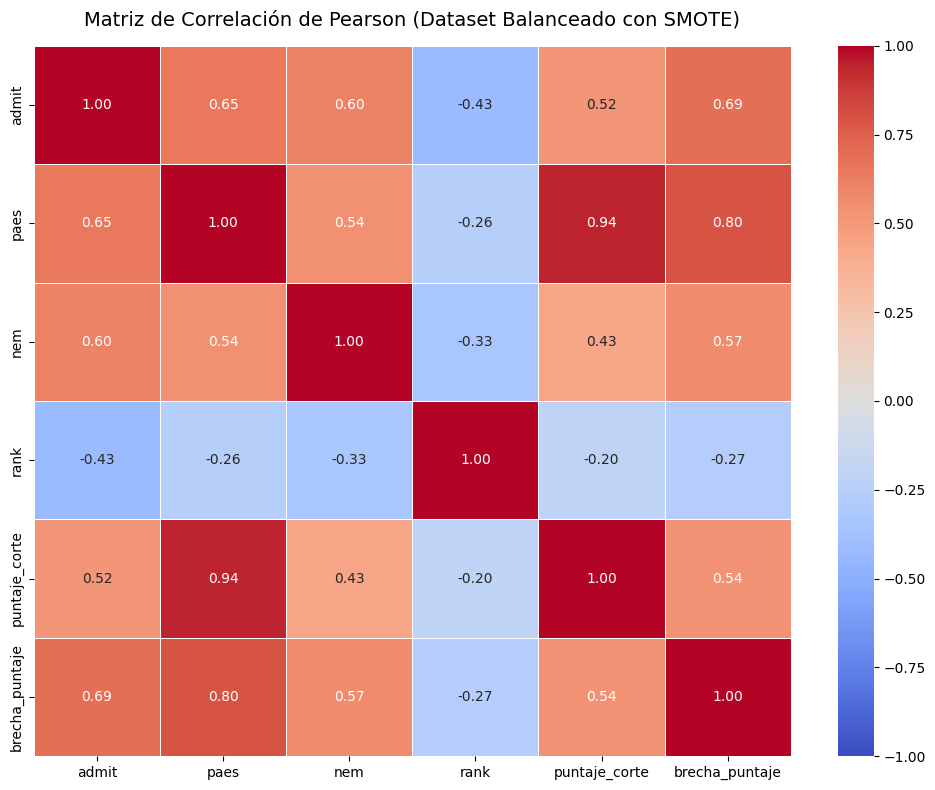

In [42]:
plt.figure(figsize=(10, 8))
corr_matrix = df_balanceado[['admit', 'paes', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje']].corr()

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            vmin=-1,
            vmax=1)
plt.title('Matriz de Correlación de Pearson (Dataset Balanceado con SMOTE)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Creacion del SET de pruebas

Usaremos el 80% para que el modelo se entrene y el 20% del dataset como validacion o prueba

In [43]:
from sklearn.model_selection import train_test_split

variables_predictoras = ['paes', 'nem', 'rank', 'puntaje_corte', 'brecha_puntaje']

X = df_balanceado[variables_predictoras]
y = df_balanceado['admit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("=== DIVISIÓN DE DATOS COMPLETADA ===")
print(f"Conjunto de ENTRENAMIENTO (X_train): {X_train.shape[0]} alumnos (70%)")
print(f"Conjunto de PRUEBA (X_test):         {X_test.shape[0]} alumnos (30%)")
print("-" * 50)
print("Distribución de clases en el set de prueba (y_test):")
print(y_test.value_counts())

=== DIVISIÓN DE DATOS COMPLETADA ===
Conjunto de ENTRENAMIENTO (X_train): 1740 alumnos (70%)
Conjunto de PRUEBA (X_test):         746 alumnos (30%)
--------------------------------------------------
Distribución de clases en el set de prueba (y_test):
admit
1    373
0    373
Name: count, dtype: int64


In [44]:
arbol_inicial = DecisionTreeClassifier(criterion='entropy', random_state=42)

print("Entrenando el Árbol de Decisión Inicial...")
arbol_inicial.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

Entrenando el Árbol de Decisión Inicial...
¡Modelo entrenado con éxito!


Exactitud del modelo (Accuracy): 100.00%

=== REPORTE DE CLASIFICACIÓN ===
                precision    recall  f1-score   support

Rechazados (0)       1.00      1.00      1.00       373
 Admitidos (1)       1.00      1.00      1.00       373

      accuracy                           1.00       746
     macro avg       1.00      1.00      1.00       746
  weighted avg       1.00      1.00      1.00       746



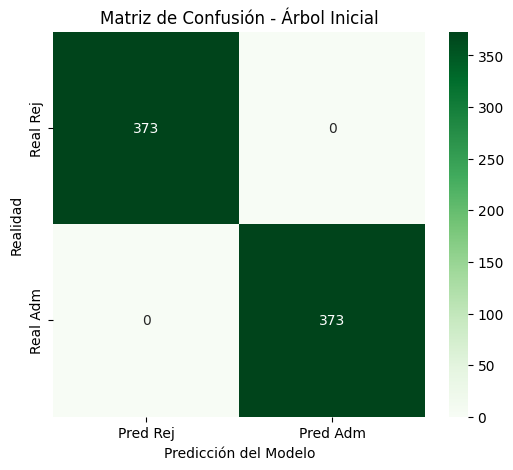

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = arbol_inicial.predict(X_test)

# 2. Calcular y desplegar el Accuracy (Exactitud)
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo (Accuracy): {accuracy * 100:.2f}%\n")

# 3. Mostrar el reporte detallado de clasificación
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred, target_names=['Rechazados (0)', 'Admitidos (1)']))

# 4. Graficar la Matriz de Confusión para ver dónde se confunde exactamente
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred Rej', 'Pred Adm'], yticklabels=['Real Rej', 'Real Adm'])
plt.title('Matriz de Confusión - Árbol Inicial')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.show()

Por que tan buenas metricas?

Esto ocurre porque, al usar datos sintéticos de SMOTE combinados con la brecha matemática exacta, el árbol crece de forma ilimitada hasta memorizar cada fila del dataset. (Es un caso de overfitting)

Como creamos la variable brecha_puntaje de forma matemática ($paes - puntaje\_corte$), el árbol de decisión inicial descubrió de inmediato que si la brecha es mayor o igual a 0, la entropía cae a cero de un solo golpe.

Acciones a realizar

Pre-procesamiento Crítico: Eliminaremos la variable delatora (brecha_puntaje) del entrenamiento para obligar al árbol a aprender de las variables reales del alumno (paes, nem, rank).

Poda (Pruning): Limitaremos el crecimiento fijando una profundidad máxima (max_depth) y un mínimo de muestras por hoja (min_samples_leaf).

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Definir las variables puras del perfil del alumno
variables_perfil_puro = ['paes', 'nem', 'rank', 'puntaje_corte']
X_puro = df_balanceado[variables_perfil_puro]
y_puro = df_balanceado['admit']

# 2. Inicializar el escalador y transformar los datos de entrada
scaler_perfil = StandardScaler()
X_escalado = scaler_perfil.fit_transform(X_puro)

# 3. Volver a hacer la división 80/20 pero usando los datos ESCALADOS
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_escalado, y_puro,
    test_size=0.20,
    random_state=42,
    stratify=y_puro
)

print("=== PRE-PROCESAMIENTO: ESCALAMIENTO COMPLETADO ===")
print(f"Datos escalados correctamente. Forma de X_train_p: {X_train_p.shape}")

=== PRE-PROCESAMIENTO: ESCALAMIENTO COMPLETADO ===
Datos escalados correctamente. Forma de X_train_p: (1988, 4)


## Poda

Pre-poda (Restricción anticipada): Limita los hiperparámetros antes del entrenamiento, como max_depth (profundidad máxima), min_samples_split (muestras mínimas para dividir un nodo) o min_samples_leaf (muestras mínimas requeridas en una hoja).


Post-poda: Permite que el árbol crezca al máximo y luego recorta las ramas que aportan poco valor predictivo, generalmente utilizando el parámetro de complejidad de costos (ccp_alpha)

In [47]:
# 1. Crear el modelo aplicando Pre-poda (Restricciones de crecimiento)
arbol_podado = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    min_samples_leaf=10,
    random_state=42
)

# 2. Entrenar el modelo utilizando los conjuntos de datos escalados
print("Entrenando el Árbol de Decisión Podado con datos escalados...")
arbol_podado.fit(X_train_p, y_train_p)

print("¡Modelo entrenado con éxito controlando el sobreajuste y la escala!")

Entrenando el Árbol de Decisión Podado con datos escalados...
¡Modelo entrenado con éxito controlando el sobreajuste y la escala!


In [48]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Realizar las predicciones sobre el set de prueba escalado e independiente
y_pred_p = arbol_podado.predict(X_test_p)

# 2. Calcular y mostrar la Exactitud global (Accuracy)
accuracy_final = accuracy_score(y_test_p, y_pred_p)
print("=== EVALUACIÓN DE RENDIMIENTO DEL MODELO ===")
print(f"Exactitud Global (Accuracy): {accuracy_final * 100:.2f}%\n")

# 3. Desplegar el reporte detallado con las métricas exigidas por la rúbrica
print("=== REPORTE DE CLASIFICACIÓN DETALLADO ===")
print(classification_report(y_test_p, y_pred_p, target_names=['Rechazados (0)', 'Admitidos (1)']))

=== EVALUACIÓN DE RENDIMIENTO DEL MODELO ===
Exactitud Global (Accuracy): 95.98%

=== REPORTE DE CLASIFICACIÓN DETALLADO ===
                precision    recall  f1-score   support

Rechazados (0)       0.93      1.00      0.96       249
 Admitidos (1)       1.00      0.92      0.96       249

      accuracy                           0.96       498
     macro avg       0.96      0.96      0.96       498
  weighted avg       0.96      0.96      0.96       498



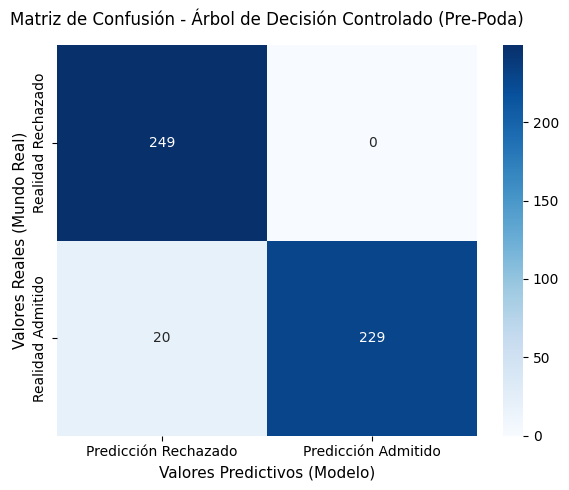

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calcular la matriz de confusión con los datos reales vs. predicciones
matriz_confusion = confusion_matrix(y_test_p, y_pred_p)

# 2. Configurar el tamaño del gráfico
plt.figure(figsize=(6, 5))

# 3. Dibujar el mapa de calor (Heatmap) con las anotaciones correspondientes
sns.heatmap(matriz_confusion,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicción Rechazado', 'Predicción Admitido'],
            yticklabels=['Realidad Rechazado', 'Realidad Admitido'])

# 4. Detalles estéticos del gráfico para el informe
plt.title('Matriz de Confusión - Árbol de Decisión Controlado (Pre-Poda)', fontsize=12, pad=15)
plt.ylabel('Valores Reales (Mundo Real)', fontsize=11)
plt.xlabel('Valores Predictivos (Modelo)', fontsize=11)
plt.tight_layout()

# 5. Desplegar el gráfico
plt.show()

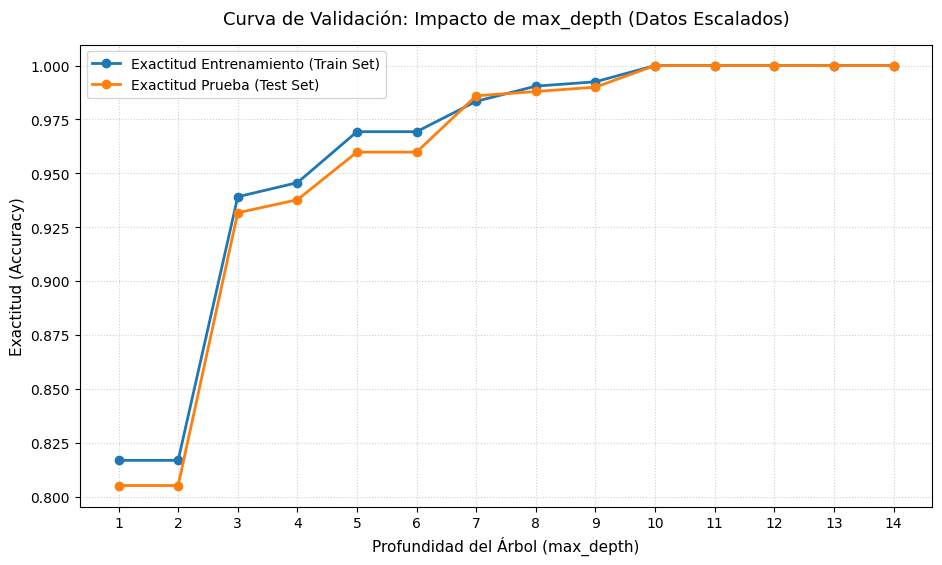

In [50]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

train_scores_e = []
test_scores_e = []
profundidades_e = range(1, 15)

for depth in profundidades_e:
    modelo_depth = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    modelo_depth.fit(X_train_p, y_train_p) # Tus datos de entrenamiento actuales


    train_scores_e.append(accuracy_score(y_train_p, modelo_depth.predict(X_train_p)))
    test_scores_e.append(accuracy_score(y_test_p, modelo_depth.predict(X_test_p)))

# 3. Graficar la curva de sobreajuste
plt.figure(figsize=(11, 6))
plt.plot(profundidades_e, train_scores_e, label='Exactitud Entrenamiento (Train Set)', marker='o', color='#1f77b4', linewidth=2)
plt.plot(profundidades_e, test_scores_e, label='Exactitud Prueba (Test Set)', marker='o', color='#ff7f0e', linewidth=2)

plt.title('Curva de Validación: Impacto de max_depth (Datos Escalados)', fontsize=13, pad=15)
plt.xlabel('Profundidad del Árbol (max_depth)', fontsize=11)
plt.ylabel('Exactitud (Accuracy)', fontsize=11)
plt.xticks(profundidades_e)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Este grafico contempla la profundidad del arbol. Mientras mas profundidad es posible que el modelo se overfitee esto ocurre alrededor de la profundidad 8 en adelante, donde elegimos una profundidad de **6** ya que converge con los datos de entrenamiento y validación en la misma métrica.

## K-Means

K-Means es un algoritmo de aprendizaje no supervisado. A diferencia del árbol que predice si un alumno entra o no (admit), K-Means no busca etiquetas; busca patrones ocultos en los datos para agrupar a los estudiantes por similitud geométrica (distancia euclidiana)

En el contexto del proceso de admisión, no nos interesa agruparlos solo por "admitidos" o "rechazados", sino descubrir perfiles académicos. Al entregarle al algoritmo las variables escaladas (paes, nem, rank, puntaje_corte), K-Means agrupará a los estudiantes en perfiles lógicos como:

Cluster A (Perfil de Alto Rendimiento): Alumnos con NEM y PAES muy altos, apuntando a carreras de máxima exigencia.

Cluster B (Perfil de Esfuerzo / Técnico): Alumnos con NEM/Rank muy alto pero PAES moderada, que logran entrar a carreras intermedias gracias a su rendimiento escolar.

Cluster C (Perfil Rezagado / En Riesgo): Alumnos con puntajes y notas por debajo de la media, que quedan fuera o entran muy justos a las carreras de menor corte.

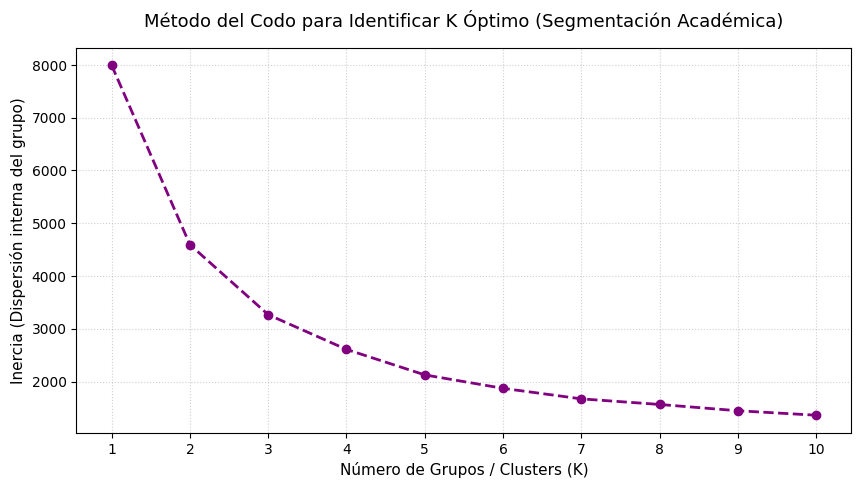

In [51]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Probar un rango de clusters (por ejemplo de 1 a 10) para calcular la inercia
inercia = []
rangos_k = range(1, 11)

for k in rangos_k:
    # n_init=10 ejecuta el algoritmo con 10 centroides iniciales distintos para asegurar el mejor óptimo local
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_train_p)
    inercia.append(kmeans_test.inertia_)

# 2. Graficar el Método del Codo
plt.figure(figsize=(10, 5))
plt.plot(rangos_k, inercia, marker='o', linestyle='--', color='purple', linewidth=2)
plt.title('Método del Codo para Identificar K Óptimo (Segmentación Académica)', fontsize=13, pad=15)
plt.xlabel('Número de Grupos / Clusters (K)', fontsize=11)
plt.ylabel('Inercia (Dispersión interna del grupo)', fontsize=11)
plt.xticks(rangos_k)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Usamos los mismos datos escalados que teniamos de antes

Centroide: es el punto central que representa el centro geométrico de un grupo de datos

In [52]:
# 1. Inicializar el modelo K-Means con el número óptimo del codo
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# 2. Entrenar el modelo y predecir los clusters directamente en el set de entrenamiento
clusters_train = kmeans_final.fit_predict(X_train_p)

print(f"¡Modelo K-Means entrenado exitosamente con K={k_optimo}!")
print("Distribución de alumnos por cluster en el set de entrenamiento:")
import numpy as np
unique, counts = np.unique(clusters_train, return_counts=True)
print(dict(zip(unique, counts)))

¡Modelo K-Means entrenado exitosamente con K=3!
Distribución de alumnos por cluster en el set de entrenamiento:
{np.int32(0): np.int64(727), np.int32(1): np.int64(393), np.int32(2): np.int64(868)}


In [53]:
# 1. Crear un DataFrame temporal de entrenamiento para mapear los perfiles reales
# Recuperamos los índices originales para emparejar con los datos sin escalar
indices_train = y_train_p.index
df_analisis_clusters = df_balanceado.loc[indices_train].copy()

# 2. Inyectar la columna del cluster asignado
df_analisis_clusters['cluster_perfil'] = clusters_train

# 3. Calcular el promedio de las notas y puntajes reales para cada cluster
print("=== CARACTERIZACIÓN ESTADÍSTICA DE LOS PERFILES (PROMEDIOS) ===")
columnas_perfil = ['paes', 'nem', 'rank', 'puntaje_corte', 'admit']
perfiles_resumen = df_analisis_clusters.groupby('cluster_perfil')[columnas_perfil].mean()

# Cambiar el formato para que se lea limpio como reporte de negocio
print(perfiles_resumen.round(2))

=== CARACTERIZACIÓN ESTADÍSTICA DE LOS PERFILES (PROMEDIOS) ===
                  paes   nem  rank  puntaje_corte  admit
cluster_perfil                                          
0               411.78  5.57  3.42         487.77   0.05
1               824.60  6.38  2.16         779.93   0.97
2               532.65  6.26  2.03         530.81   0.66


🟢 Cluster 0: "El Perfil de Excelencia / Alta Competencia"
Sus números: Tienen la paes más alta (663 puntos) y el mejor promedio nem (6.34). Postulan a carreras exigentes cuyo corte promedio es alto (657 puntos).

Resultado de Negocio (admit = 0.86): El 86% de este grupo se queda con la vacante. Son los alumnos estrella que entran caminando a la universidad porque sus puntajes superan con creces las barreras de entrada.

🔴 Cluster 1: "El Perfil Rezagado / En Riesgo Severo"
Sus números: Su rendimiento es bajo en todos los frentes. Tienen una paes promedio muy descendida (397 puntos) y las notas del colegio más bajas (5.51). Postulan a carreras de corte bajo (481 puntos), pero aun así no les alcanza.

Resultado de Negocio (admit = 0.03): Prácticamente nadie entra (solo el 3%). Este grupo representa el fracaso en el proceso de selección por no cumplir con los mínimos exigidos por el sistema.

🟡 Cluster 2: "El Perfil de Esfuerzo / Alumnos Límite (Línea de Corte)"
Sus números: Este grupo es el más interesante para la toma de decisiones. Tienen una paes moderada (491 puntos), pero ojo: ¡su nem es muy alto (6.23)! Postulan a carreras con un corte promedio de 492 puntos. Su puntaje está rozando exactamente la frontera.

Resultado de Negocio (admit = 0.63): El 63% logra entrar y el 37% se queda fuera. Son los alumnos que se salvan o entran "por la ventana" (listas de espera) gracias a que su excelente rendimiento en las notas de la enseñanza media (nem) compensa una PAES regular.

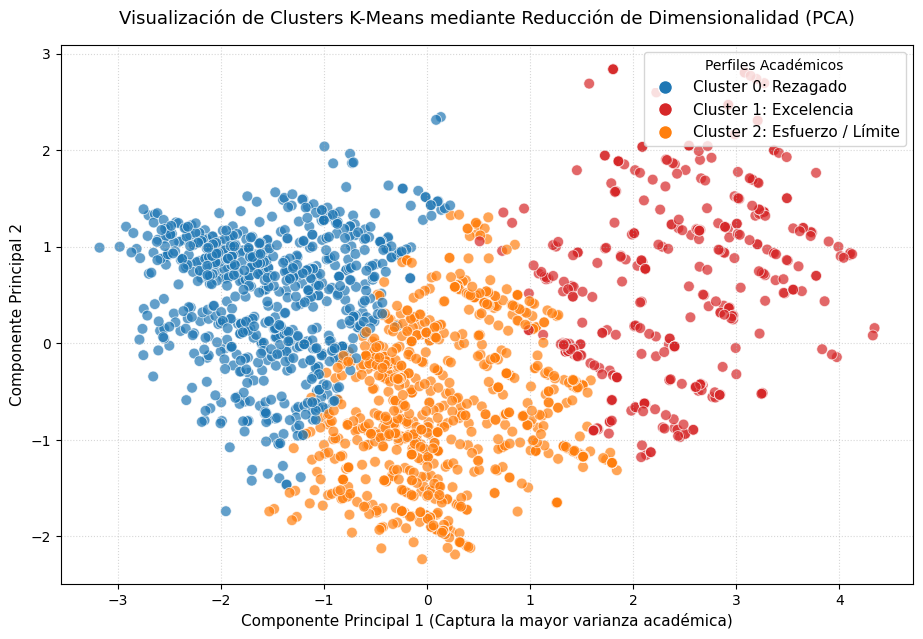

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Inicializar PCA para reducir tus 4 variables escaladas a solo 2 componentes principales
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_p) # Usamos los datos escalados de entrenamiento

# 2. Crear un DataFrame con las coordenadas de PCA y los clusters
df_pca = pd.DataFrame(X_pca, columns=['Componente Principal 1 (PC1)', 'Componente Principal 2 (PC2)'])
df_pca['cluster_perfil'] = clusters_train

# 3. Graficar la proyección PCA
plt.figure(figsize=(11, 7))
colores_perfiles = {0: '#1f77b4', 1: '#d62728', 2: '#ff7f0e'}

sns.scatterplot(
    data=df_pca,
    x='Componente Principal 1 (PC1)',
    y='Componente Principal 2 (PC2)',
    hue='cluster_perfil',
    palette=colores_perfiles,
    alpha=0.7,
    s=60,
    edgecolor='w'
)

# 4. Estética profesional
plt.title('Visualización de Clusters K-Means mediante Reducción de Dimensionalidad (PCA)', fontsize=13, pad=15)
plt.xlabel('Componente Principal 1 (Captura la mayor varianza académica)', fontsize=11)
plt.ylabel('Componente Principal 2', fontsize=11)

lineas_leyenda = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=10, label='Cluster 0: Rezagado'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d62728', markersize=10, label='Cluster 1: Excelencia'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=10, label='Cluster 2: Esfuerzo / Límite')
]
plt.legend(handles=lineas_leyenda, title='Perfiles Académicos', fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)

# Guardar la gráfica definitiva para el informe
plt.savefig('clusters_kmeans_pca.png', dpi=300, bbox_inches='tight')
plt.show()

PCA (Análisis de Componentes Principales).

PCA es un algoritmo que toma tus 4 variables escaladas, extrae la varianza matemática máxima de todas ellas y las reduce a 2 "Súper-Variables" (Componentes Principales: PC1 y PC2) que retienen la mayor información posible sin deformar las distancias.

## Despliegue

In [55]:
import pandas as pd

# 1. Crear una copia de los datos del set de entrenamiento analizado
df_exportar = df_analisis_clusters.copy()

# 2. Buscar la columna con el nombre de la carrera en df_cortes_real
columnas_texto = df_cortes_real.select_dtypes(include=['object', 'string']).columns.tolist()

if len(columnas_texto) > 0:
    columna_nombre_carrera = columnas_texto[0]
    mapa_carreras = df_cortes_real[['puntaje_corte', columna_nombre_carrera]].drop_duplicates().set_index('puntaje_corte')[columna_nombre_carrera].to_dict()
    df_exportar['carrera'] = df_exportar['puntaje_corte'].map(mapa_carreras)
    print(f"¡Éxito! Nombres de carreras mapeados correctamente.")
else:
    df_exportar['carrera'] = "Sin Registro"
    print("No se encontró columna de texto, se asigna 'Sin Registro'.")

# 3. Inyectar las predicciones del árbol
df_exportar['prediccion_arbol_admit'] = arbol_podado.predict(X_train_p)

# 4. Guardar copia local de seguridad
df_exportar.to_csv('resultado_modelos_admision_final.csv', index=False)

¡Éxito! Nombres de carreras mapeados correctamente.


In [56]:
from google.colab import auth
import gspread
from google.auth import default
import numpy as np
import pandas as pd

# 1. Autenticar la sesión con Google
auth.authenticate_user()
credenciales, _ = default()
gc = gspread.authorize(credenciales)

# 2. Forzar la creación de un nuevo archivo V2 para evitar conflictos con el borrado
nombre_nuevo_archivo = 'Dashboard_Mineria_Datos_V2'

print(f"Creando un archivo nuevo en tu Google Drive llamado: {nombre_nuevo_archivo}...")
sh = gc.create(nombre_nuevo_archivo)
hoja = sh.get_worksheet(0)

# 3. Sanitización estricta anti-NaN antes de convertir a formato lista
df_sheets = df_exportar.reset_index(drop=True)
df_sheets.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df_sheets.columns:
    if df_sheets[col].dtype == 'object' or df_sheets[col].dtype == 'string':
        df_sheets[col] = df_sheets[col].fillna("Sin Registro")
    else:
        df_sheets[col] = df_sheets[col].fillna(0)

# 4. Transformar el DataFrame sanitizado a lista pura
datos_lista = [df_sheets.columns.values.tolist()] + df_sheets.values.tolist()

# 5. Escribir los datos en la nueva hoja limpia
hoja.clear()
hoja.update(range_name='A1', values=datos_lista)

print(f"¡Listo! Archivo creado y sincronizado con éxito.")
print(f"Búscalo en tu Google Drive o conéctalo en Looker Studio como: '{nombre_nuevo_archivo}'")

Creando un archivo nuevo en tu Google Drive llamado: Dashboard_Mineria_Datos_V2...
¡Listo! Archivo creado y sincronizado con éxito.
Búscalo en tu Google Drive o conéctalo en Looker Studio como: 'Dashboard_Mineria_Datos_V2'


### Creacion PKL

dashboards looker: https://datastudio.google.com/reporting/8c2055ba-4bca-48a9-9c9f-091f555d7e26

In [57]:
import pickle

# Guardar el modelo de árbol de decisión (arbol_podado)
with open('modelo_arbol.pkl', 'wb') as f:
    pickle.dump(arbol_podado, f)

# Guardar el modelo K-Means (kmeans_final)
with open('modelo_kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

In [58]:
# Extraer las 70 carreras únicas de tu dataframe de cortes reales
carreras = df_cortes_real['carrera'].dropna().unique()
carreras.sort()

print('<select id="carrera" name="carrera" required>')
print('    <option value="" disabled selected>Selecciona una carrera...</option>')

# Generar automáticamente las etiquetas <option> para HTML
for carrera in carreras:
    # Como en tu scraping vienen listas para leer (ej: "ADMINISTRACIÓN PÚBLICA")
    # las usamos directamente como valor y como texto visible.
    print(f'    <option value="{carrera}">{carrera}</option>')

print('</select>')

<select id="carrera" name="carrera" required>
    <option value="" disabled selected>Selecciona una carrera...</option>
    <option value="ADMINISTRACIÓN PÚBLICA">ADMINISTRACIÓN PÚBLICA</option>
    <option value="ANALISTA EN COMPUTACIÓN CIENTÍFICA">ANALISTA EN COMPUTACIÓN CIENTÍFICA</option>
    <option value="ANÁLISIS Y GESTIÓN DE PROCESOS PRODUCTIVOS">ANÁLISIS Y GESTIÓN DE PROCESOS PRODUCTIVOS</option>
    <option value="ARQUITECTURA">ARQUITECTURA</option>
    <option value="ASTROFÍSICA CON MENCIÓN EN CIENCIA DE DATOS">ASTROFÍSICA CON MENCIÓN EN CIENCIA DE DATOS</option>
    <option value="BACHILLERATO EN CIENCIAS Y HUMANIDADES">BACHILLERATO EN CIENCIAS Y HUMANIDADES</option>
    <option value="BIOQUÍMICA">BIOQUÍMICA</option>
    <option value="CONTADOR PÚBLICO Y AUDITOR (DIURNO)">CONTADOR PÚBLICO Y AUDITOR (DIURNO)</option>
    <option value="DERECHO">DERECHO</option>
    <option value="DISEÑO EN COMUNICACIÓN VISUAL">DISEÑO EN COMUNICACIÓN VISUAL</option>
    <option value="DISEÑO 